# Spectral Analysis Big (Many Runs)

This notebook aggregates many spectral detections (up to `MAX_RUNS`) from `analysis_out/*.json` and visualizes:

- Signal A (`sv_z_scores`) across many runs
- Signal B (`sv_ratio_scores`) across many runs
- Distribution-focused plots (percentile bands, density, violin, peak-layer histograms)

It is designed for large samples (e.g., 1000 runs) while keeping plots readable.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

MAX_RUNS = 1000
INCLUDE_BASELINE = True
RANDOM_SEED = 7


def find_repo_root() -> Path:
    cwd = Path.cwd()
    candidates = [cwd, *cwd.parents]
    for candidate in candidates:
        if (candidate / "analysis_out").exists():
            return candidate
    return cwd


def to_int_float_map(d):
    return {int(k): float(v) for k, v in (d or {}).items()}


def collect_spectral_entries(payload: dict, run_path: Path, include_baseline: bool = True):
    entries = []

    if include_baseline:
        baseline = payload.get("baseline_spectral", payload.get("baseline_spectral_bin", {}))
        a_map = to_int_float_map(baseline.get("sv_z_scores", {}))
        b_map = to_int_float_map(baseline.get("sv_ratio_scores", {}))
        if a_map:
            entries.append(
                {
                    "source": "baseline",
                    "run_file": run_path.name,
                    "case_id": "baseline",
                    "a_map": a_map,
                    "b_map": b_map,
                }
            )

    for test in payload.get("tests", []):
        if test.get("skipped", False):
            continue
        block = test.get("spectral_detection", test.get("spectral_bin_detection", {}))
        a_map = to_int_float_map(block.get("sv_z_scores", {}))
        b_map = to_int_float_map(block.get("sv_ratio_scores", {}))
        if not a_map:
            continue
        entries.append(
            {
                "source": "test",
                "run_file": run_path.name,
                "case_id": test.get("case_id", "N/A"),
                "a_map": a_map,
                "b_map": b_map,
            }
        )

    return entries

In [2]:
ROOT = find_repo_root()
ANALYSIS_DIR = ROOT / "analysis_out"
run_files = sorted(ANALYSIS_DIR.glob("*.json"), key=lambda p: p.stat().st_mtime, reverse=True)

all_entries = []
for run_path in run_files:
    try:
        with open(run_path, "r") as f:
            payload = json.load(f)
        all_entries.extend(collect_spectral_entries(payload, run_path, include_baseline=INCLUDE_BASELINE))
    except Exception:
        continue

if not all_entries:
    raise ValueError(f"No spectral entries found under {ANALYSIS_DIR}")

if len(all_entries) > MAX_RUNS:
    rng = np.random.default_rng(RANDOM_SEED)
    keep_idx = rng.choice(len(all_entries), size=MAX_RUNS, replace=False)
    entries = [all_entries[i] for i in sorted(keep_idx)]
else:
    entries = all_entries

all_layers = sorted(
    set().union(*[set(e["a_map"].keys()) for e in entries], *[set(e["b_map"].keys()) for e in entries if e["b_map"]])
)

n_runs = len(entries)
n_layers = len(all_layers)

a_matrix = np.full((n_runs, n_layers), np.nan)
b_matrix = np.full((n_runs, n_layers), np.nan)

for i, entry in enumerate(entries):
    for j, layer in enumerate(all_layers):
        a_matrix[i, j] = entry["a_map"].get(layer, np.nan)
        b_matrix[i, j] = entry["b_map"].get(layer, np.nan)

print(f"JSON files scanned: {len(run_files)}")
print(f"Spectral entries collected: {len(all_entries)}")
print(f"Entries used for plots: {n_runs} (MAX_RUNS={MAX_RUNS})")
print(f"Layers in view: {n_layers} ({all_layers[0]}..{all_layers[-1]})")
print(f"Entries with Signal B: {int(np.sum(np.isfinite(np.nanmax(b_matrix, axis=1))))}")

JSON files scanned: 11
Spectral entries collected: 311
Entries used for plots: 311 (MAX_RUNS=1000)
Layers in view: 48 (0..47)
Entries with Signal B: 311


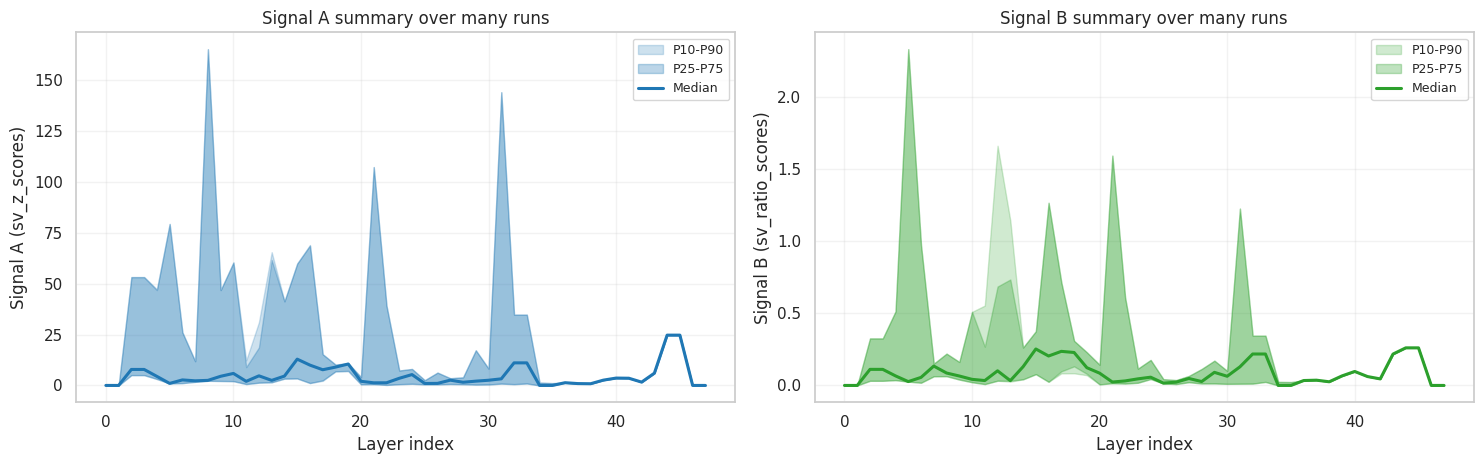

In [3]:
def nanpercentile_rows(matrix: np.ndarray, q):
    return np.nanpercentile(matrix, q=q, axis=0)


q10_a, q25_a, q50_a, q75_a, q90_a = [nanpercentile_rows(a_matrix, q) for q in [10, 25, 50, 75, 90]]

fig, axes = plt.subplots(1, 2, figsize=(15, 4.8), sharex=True)

axes[0].fill_between(all_layers, q10_a, q90_a, alpha=0.22, color="tab:blue", label="P10-P90")
axes[0].fill_between(all_layers, q25_a, q75_a, alpha=0.30, color="tab:blue", label="P25-P75")
axes[0].plot(all_layers, q50_a, color="tab:blue", linewidth=2.2, label="Median")
axes[0].set_title("Signal A summary over many runs")
axes[0].set_xlabel("Layer index")
axes[0].set_ylabel("Signal A (sv_z_scores)")
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.25)

if np.isfinite(b_matrix).any():
    q10_b, q25_b, q50_b, q75_b, q90_b = [nanpercentile_rows(b_matrix, q) for q in [10, 25, 50, 75, 90]]
    axes[1].fill_between(all_layers, q10_b, q90_b, alpha=0.22, color="tab:green", label="P10-P90")
    axes[1].fill_between(all_layers, q25_b, q75_b, alpha=0.30, color="tab:green", label="P25-P75")
    axes[1].plot(all_layers, q50_b, color="tab:green", linewidth=2.2, label="Median")
    axes[1].set_title("Signal B summary over many runs")
    axes[1].set_xlabel("Layer index")
    axes[1].set_ylabel("Signal B (sv_ratio_scores)")
    axes[1].legend(fontsize=9)
    axes[1].grid(alpha=0.25)
else:
    axes[1].text(0.5, 0.5, "No Signal B found", ha="center", va="center", transform=axes[1].transAxes)
    axes[1].set_axis_off()

plt.tight_layout()
plt.show()

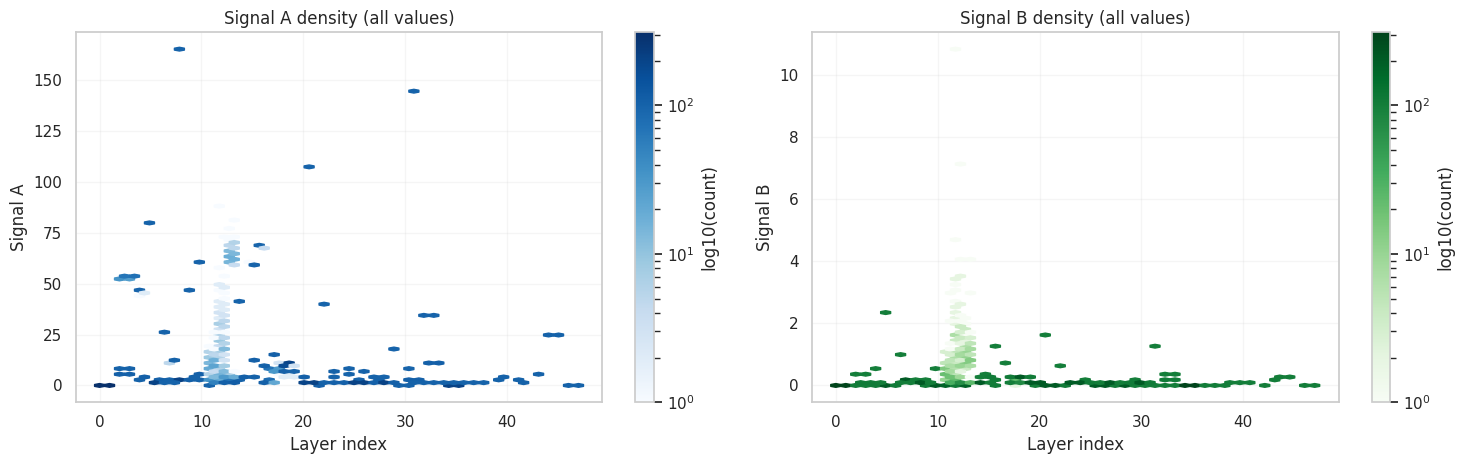

In [4]:
layer_grid = np.tile(np.array(all_layers), n_runs)

df_a = pd.DataFrame(
    {
        "layer": layer_grid,
        "value": a_matrix.reshape(-1),
        "signal": "A",
    }
).dropna(subset=["value"])

df_b = pd.DataFrame(
    {
        "layer": layer_grid,
        "value": b_matrix.reshape(-1),
        "signal": "B",
    }
).dropna(subset=["value"])

fig, axes = plt.subplots(1, 2, figsize=(15, 4.8), sharex=True)

hb_a = axes[0].hexbin(df_a["layer"], df_a["value"], gridsize=(n_layers, 60), bins="log", cmap="Blues", mincnt=1)
axes[0].set_title("Signal A density (all values)")
axes[0].set_xlabel("Layer index")
axes[0].set_ylabel("Signal A")
axes[0].grid(alpha=0.18)
fig.colorbar(hb_a, ax=axes[0], label="log10(count)")

if not df_b.empty:
    hb_b = axes[1].hexbin(df_b["layer"], df_b["value"], gridsize=(n_layers, 60), bins="log", cmap="Greens", mincnt=1)
    axes[1].set_title("Signal B density (all values)")
    axes[1].set_xlabel("Layer index")
    axes[1].set_ylabel("Signal B")
    axes[1].grid(alpha=0.18)
    fig.colorbar(hb_b, ax=axes[1], label="log10(count)")
else:
    axes[1].text(0.5, 0.5, "No Signal B found", ha="center", va="center", transform=axes[1].transAxes)
    axes[1].set_axis_off()

plt.tight_layout()
plt.show()

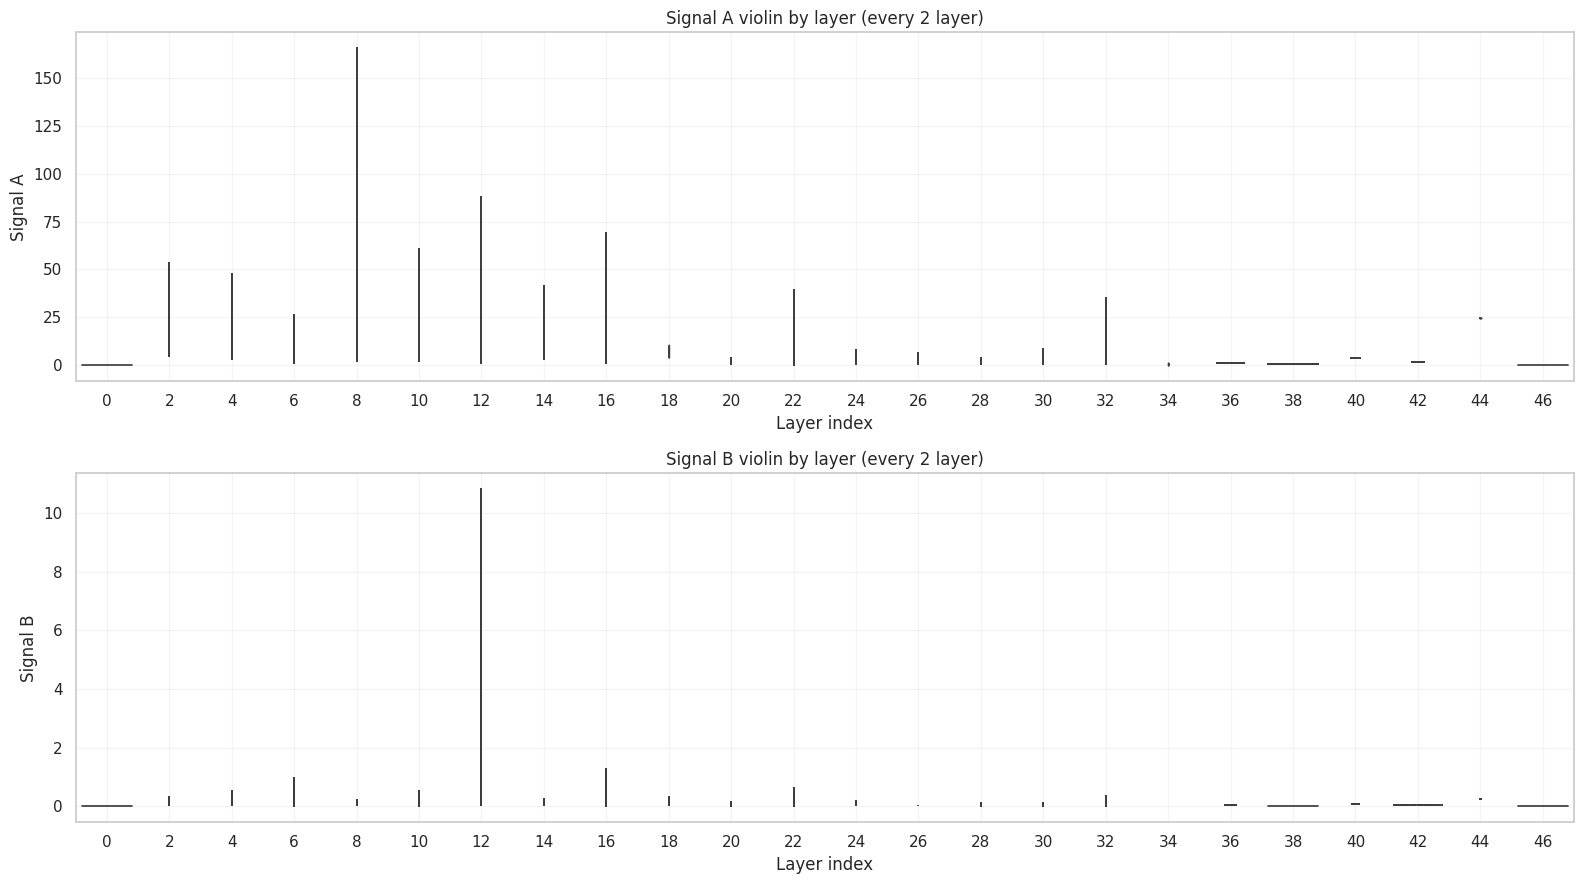

In [5]:
layer_stride = max(1, n_layers // 18)
selected_layers = all_layers[::layer_stride]

fig, axes = plt.subplots(2, 1, figsize=(16, 9), sharex=False)

df_a_violin = df_a[df_a["layer"].isin(selected_layers)].copy()
sns.violinplot(data=df_a_violin, x="layer", y="value", inner="quartile", cut=0, ax=axes[0], color="tab:blue")
axes[0].set_title(f"Signal A violin by layer (every {layer_stride} layer)")
axes[0].set_xlabel("Layer index")
axes[0].set_ylabel("Signal A")
axes[0].grid(alpha=0.2)

if not df_b.empty:
    df_b_violin = df_b[df_b["layer"].isin(selected_layers)].copy()
    sns.violinplot(data=df_b_violin, x="layer", y="value", inner="quartile", cut=0, ax=axes[1], color="tab:green")
    axes[1].set_title(f"Signal B violin by layer (every {layer_stride} layer)")
    axes[1].set_xlabel("Layer index")
    axes[1].set_ylabel("Signal B")
    axes[1].grid(alpha=0.2)
else:
    axes[1].text(0.5, 0.5, "No Signal B found", ha="center", va="center", transform=axes[1].transAxes)
    axes[1].set_axis_off()

plt.tight_layout()
plt.show()

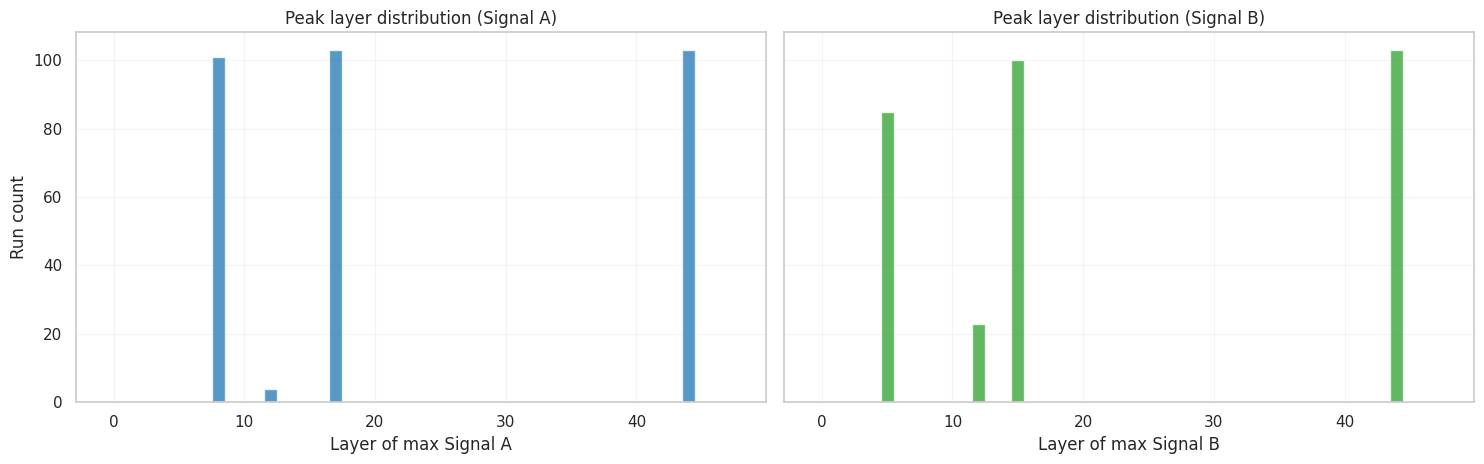

In [6]:
def peak_layer_per_run(matrix: np.ndarray, layers):
    peaks = []
    for row in matrix:
        if not np.isfinite(row).any():
            peaks.append(np.nan)
            continue
        idx = int(np.nanargmax(row))
        peaks.append(layers[idx])
    return np.array(peaks, dtype=float)


peak_a = peak_layer_per_run(a_matrix, all_layers)
peak_b = peak_layer_per_run(b_matrix, all_layers)

bins = np.arange(min(all_layers) - 0.5, max(all_layers) + 1.5, 1)

fig, axes = plt.subplots(1, 2, figsize=(15, 4.8), sharey=True)

axes[0].hist(peak_a[np.isfinite(peak_a)], bins=bins, color="tab:blue", alpha=0.75, edgecolor="white")
axes[0].set_title("Peak layer distribution (Signal A)")
axes[0].set_xlabel("Layer of max Signal A")
axes[0].set_ylabel("Run count")
axes[0].grid(alpha=0.2)

if np.isfinite(peak_b).any():
    axes[1].hist(peak_b[np.isfinite(peak_b)], bins=bins, color="tab:green", alpha=0.75, edgecolor="white")
    axes[1].set_title("Peak layer distribution (Signal B)")
    axes[1].set_xlabel("Layer of max Signal B")
    axes[1].grid(alpha=0.2)
else:
    axes[1].text(0.5, 0.5, "No Signal B found", ha="center", va="center", transform=axes[1].transAxes)
    axes[1].set_axis_off()

plt.tight_layout()
plt.show()